Step 1: Data Preparation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Step 2: Load the Dataset

In [3]:
dataset  = pd.read_csv("C:\Machine Learning\Diabetes_dataset\diabetes.csv")
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
dataset.shape

(768, 9)

In [5]:
dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(dataset.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [7]:
print(X.shape)
print(y.shape)


(768, 8)
(768,)


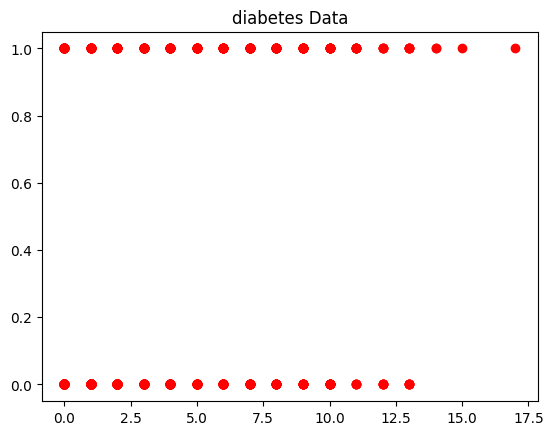

In [8]:
# Check the dataset is linear or not
plt.scatter(X[:,0],y,color="Red")
plt.title("diabetes Data")
plt.show()

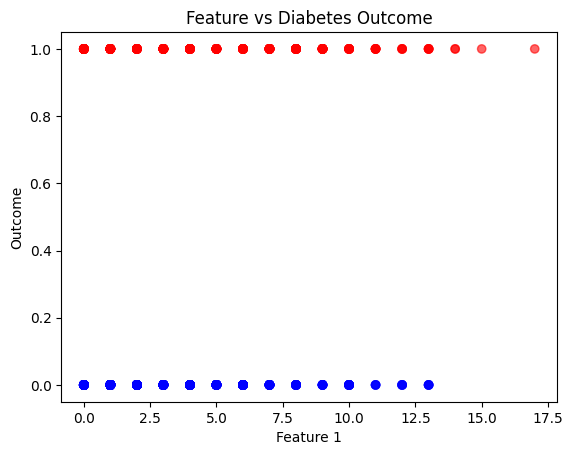

In [9]:
plt.scatter(X[:, 0], y, c=y, cmap="bwr", alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Outcome")
plt.title("Feature vs Diabetes Outcome")
plt.show()


In [10]:
X=dataset['Outcome']
y=dataset['BMI']

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("C:\Machine Learning\Diabetes_dataset\diabetes.csv")   # change path if needed

# Input and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale + Logistic Regression
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


X shape: (768, 8)
y shape: (768,)
Accuracy: 0.7142857142857143

Confusion Matrix:
 [[82 18]
 [26 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



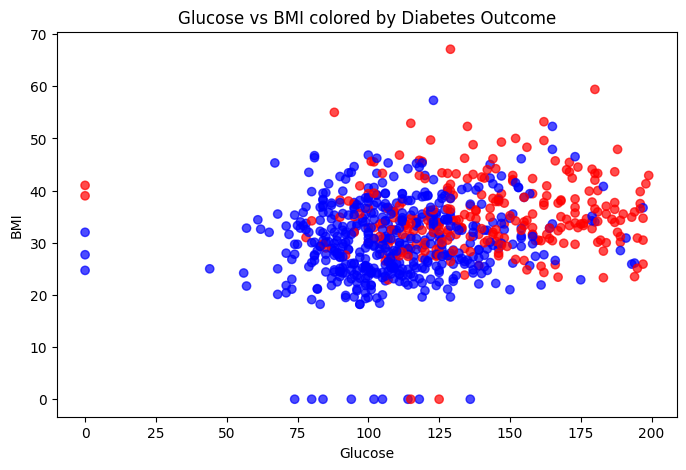

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["Glucose"], df["BMI"], c=df["Outcome"], cmap="bwr", alpha=0.7)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI colored by Diabetes Outcome")
plt.show()
